<a name='T'>

<p style="padding: 20px;
          background-color: black;
          font-family: computermodern;
          color: white;
          font-size: 200%;
          text-align: center;
          border-radius: 40px 20px;
          ">No-AI Coding Challenge #3 🩶 AND, OR, Sort!<br>
          </p>
<p style="font-family: computermodern;
          color: #000000;
          font-size: 175%;
          text-align: center;
          ">Programming Puzzle, "Newbie" Difficulty (1000 Elo)
             </p>

Welcome to my **No-AI Coding series**! This is intended to any programmer willing to keep their brain sharp in a world where AI usually codes everything for you.

Today, I propose an easy problem to warm up: the [AND, OR, Sort!](https://codeforces.com/problemset/problem/2266/C) puzzle from CodeForces. Let's dive into it!

<a id="TOC"></a>

<div style="background-color: #f5f5f5; border-left: 10px solid #9e9e9e; padding: 20px; margin-bottom: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
    <h3 style="color: #616161;">Table of Contents</h3>
    <ul style="list-style-type: none;">
        <li><a href="#s1" style="color: #424242;"><strong>1. Instructions</strong></a></li>
        <li><a href="#s2" style="color: #424242;"><strong>2. Input and Output</strong></a></li>
        <li><a href="#s3" style="color: #424242;"><strong>3. Show Time!</strong></a></li>
        <li><a href="#s4" style="color: #424242;"><strong>4. Evaluation</strong></a></li>
        <li><a href="#s5" style="color: #424242;"><strong>5. Proposed Solution</strong></a></li>
    </ul>
</div>

*Notebook by Ir. Alexandre Le Mercier.*

In [1]:
import sys
import subprocess
from pathlib import Path

# Reuse a local checkout, including when running from a nearby notebook folder.
required_files = ('utils.py', 'cha3_utils.py', 'cha3_tests.txt')
repo_path = next((
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / 'no-ai-coding-challenges', parent / 'No AI Coding Challenges')
    if all((candidate / name).is_file() for name in required_files)
), None)

# Kaggle (or a standalone local notebook): clone when no checkout is available.
if repo_path is None:
    repo_path = Path.cwd() / 'no-ai-coding-challenges'
    subprocess.run(['git', 'clone', 'https://github.com/TortueSagace/no-ai-coding-challenges.git', str(repo_path), '-q'], check=True)

repo_path = str(repo_path.resolve())
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

from utils import *
from cha3_utils import *

C:\Users\Administrator\OneDrive - UGent\PhD\PhD Related Python Codes\chess-maml\chess-hispa\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id="s1"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>1. Instructions</h1>
</div>

[Back to table of contents](#TOC)

***This problem is meant to be entirely solved without AI! Time to do some brain work-out*** 💪

You are given a **binary string**$^{\text{∗}}$ $s$ of length $n$.

You may perform the following operation any number of times (possibly zero):

- choose an integer $i$ ($1 \le i \le n$), and replace $s_i$ with either the [bitwise AND](https://en.wikipedia.org/wiki/Bitwise_operation#AND) or the [bitwise OR](https://en.wikipedia.org/wiki/Bitwise_operation#OR) of $s_1, s_2, \ldots, s_i$.

Note that the bitwise AND or bitwise OR of a single element is equal to the element itself.

Your goal is to make $s$ sorted in non-decreasing order $^{\text{†}}$.

Find the minimum number of operations required to sort $s$ in non-decreasing order.

$^{\text{∗}}$ A binary string only contains characters $\texttt{0}$ and $\texttt{1}$.

$^{\text{†}}$ If $s$ is in non-decreasing order, then $s_1 \leq s_2 \leq \ldots \leq s_n$.

Quick Definitions:

- **AND of s₁, …, sᵢ**: equals `1` if all of s₁, …, sᵢ are `1`, and `0` otherwise.
- **OR of s₁, …, sᵢ**: equals `1` if at least one of s₁, …, sᵢ is `1`, and `0` otherwise.
- **Sorted**: only the final string matters: it must satisfy s₁ ≤ s₂ ≤ … ≤ sₙ, i.e. look like `0…01…1`. An operation overwrites a character instead of moving it, so the numbers of `0`s and `1`s may change (e.g. `1000` can end as `1111`).

<a id="s2"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>2. Input and Output</h1>
</div>

[Back to table of contents](#TOC)

## Input

Your function receives:
- `n` (int): the length of the string (`2 ≤ n ≤ 10⁴`)
- `s` (list of int): the binary string as a list of `0`s and `1`s

**Example:**

```python
n = 8
s = [0, 1, 0, 0, 1, 1, 0, 1]
```

## Output

Your function must return an int `ops`: the minimum number of operations required to sort s in non-decreasing order.

**Example:**

```python
ops = 2
```

## Sample Test Cases

| n | s | Expected Output | Explanation |
|---|---|-----------------|-------------|
| 4 | `[0, 0, 1, 1]` | `0` | `0011` is already sorted → 0 operations |
| 4 | `[1, 0, 0, 0]` | `3` | s₁ = `1` can never change, so the only reachable sorted string is `1111`: OR on positions 2, 3, 4 → 3 operations |
| 5 | `[0, 1, 0, 0, 0]` | `1` | AND on position 2 → `00000` |
| 8 | `[0, 1, 0, 0, 1, 1, 0, 1]` | `2` | AND on position 2 and OR on position 7 → `00001111` |
| 7 | `[0, 1, 0, 1, 0, 1, 0]` | `3` | AND on positions 2, 4, 6 → `0000000` |
| 7 | `[0, 1, 1, 1, 1, 0, 1]` | `1` | OR on position 6 → `0111111` |

<a id="s3"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>3. Show Time!</h1>
</div>

[Back to table of contents](#TOC)

***Time to shine! Try solving the problem by yourself. You can do it!*** 🧠

Implement your solution in the `my_solution(n, s)` function below. The function should return `ops` as described above.

**Time limit per test**: 2 seconds.

**Memory limit per test**: 256 megabytes.

In [2]:
######################### SETUP ############################

samples = [
    [4, [0, 0, 1, 1]],
    [4, [1, 0, 0, 0]],
    [5, [0, 1, 0, 0, 0]],
    [8, [0, 1, 0, 0, 1, 1, 0, 1]],
    [7, [0, 1, 0, 1, 0, 1, 0]],
    [7, [0, 1, 1, 1, 1, 0, 1]]
]

TIME_LIMIT = 2
MEMORY_LIMIT = 256e6

print(f"Loaded {len(samples)} sample test cases.")

Loaded 6 sample test cases.


In [3]:
######################### RESOLUTION ###########################

def my_solution(n, s):
    """
    An operation replaces s_i with the AND or the OR of the prefix s_1, ..., s_i.
    Return the minimum number of operations required to sort s in non-decreasing order.
    
    Parameters:
    -----------
    n : int
        The length of the string (2 ≤ n ≤ 10⁴)
    s : list of int
        The binary string as a list of 0s and 1s
    
    Returns:
    --------
    int : the minimum number of operations required to sort s in non-decreasing order
    """
    
    # --> Your solution here! <--
    
    pass  # Remove this and return ops

ℹ️ **Tips**
- Run the cell below to test your solution on the sample test cases.
- Each test case has exactly one correct answer.

In [4]:
##################### ACCURACY AND EFFICIENCY CHECK ########################

try:
    evaluate_on_samples(samples, my_solution, check_solution, TIME_LIMIT, MEMORY_LIMIT)
except Exception as e:
    print(e)


                           Sample Test Results                           
   # │ Input                         │ Output │         Time │ Status    
─────┼───────────────────────────────┼────────┼──────────────┼───────────
   1 │ [4, [0, 0, 1, 1]]             │ None   │      20.7 μs │ ❌ Wrong   
   2 │ [4, [1, 0, 0, 0]]             │ None   │       3.6 μs │ ❌ Wrong   
   3 │ [5, [0, 1, 0, 0, 0]]          │ None   │       3.6 μs │ ❌ Wrong   
   4 │ [8, [0, 1, 0, 0, 1, 1, 0, 1]] │ None   │       3.4 μs │ ❌ Wrong   
   5 │ [7, [0, 1, 0, 1, 0, 1, 0]]    │ None   │       3.8 μs │ ❌ Wrong   
   6 │ [7, [0, 1, 1, 1, 1, 0, 1]]    │ None   │       2.9 μs │ ❌ Wrong   

❌  0/6 sample tests passed
    First failure: Invalid output: function returned None. Did you run the cell containing your solution?


<a id="s4"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>4. Evaluation</h1>
</div>

[Back to table of contents](#TOC)

Run the cell below to evaluate your solution on 300 hidden test cases. You are supposed to be already confident about your solution before doing this. Please note that in competitive programming, submitting several wrong answers to the tester results in time penalties. However, feel free to run the cell above with `evaluate_on_samples` as many times as you like!

In [5]:
##################### INTERNAL EVALUATION ########################

test_file_path = str(Path(repo_path) / 'cha3_tests.txt')

try:
    if internal_evaluation(test_file_path, my_solution, check_solution, parse_tests, TIME_LIMIT, MEMORY_LIMIT, get_input_size=get_input_size, plot_title='AND, OR, Sort!', show_estimation=True):
        print("✅ The proposed solution meets both accuracy and efficiency requirements")
except Exception as e:
    print(e)

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]


❌  Invalid output: function returned None. Did you run the cell containing your solution?


<a id="s5"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>5. Proposed Solution</h1>
</div>

[Back to table of contents](#TOC)

Here is a correct solution. It doesn't necessarily mean that it is the *only* correct one.

<details>
<summary><strong>💡 Click to reveal Solution Explanation</strong></summary>

<div style="color: black; background-color: #cce5ff; padding: 10px; border-left: 5px solid #3399ff; border-radius: 5px; margin-top: 10px;">
    The key insight is that <strong>s₁ can never change</strong>: the AND or OR of a single element is the element itself. Every other position can be set freely, within limits:
    <ul>
        <li>If s₁ = 1, the OR of any prefix is 1, so any 0 can become 1 in one operation.</li>
        <li>If s₁ = 0, the AND of any prefix is 0, so any position can become 0 in one operation; a 0 can become 1 with OR as soon as a 1 appears before it.</li>
    </ul>
    <strong>Strategy:</strong>
    <ol>
        <li>If s₁ = 1, the sorted string must start with 1, so it is <code>11…1</code>. Return the number of 0s: each one needs exactly one OR operation.</li>
        <li>If s₁ = 0, the sorted string is k zeros followed by n − k ones, with k ≥ 1. Turning s into it costs (number of 1s among s₁…sₖ) + (number of 0s among sₖ₊₁…sₙ).</li>
        <li>Scan k from 1 to n while updating both counts, and return the smallest cost.</li>
    </ol>
    <strong>Why it is correct:</strong> every position that differs from the final sorted string needs at least one operation, so the answer is at least the number of mismatches for the best reachable target. That cost is also achievable. Take a split k with minimal cost: if sₖ₊₁ were 0, moving the split to k + 1 would save one operation. So sₖ₊₁ is an original 1 that we never touch, and every 0 after it can be turned into 1 with OR. The 1s before the split are turned into 0s with AND. The scan is a single pass, so it runs in O(n) time and O(1) extra memory.
</div>

</details><br>

The time complexity of this solution is $\mathcal O(n)$ and its space complexity is $\mathcal O(1)$.

In [6]:
######################### PROPOSED SOLUTION ###########################

def proposed_solution(n, s):
    """
    s[0] can never change (the AND/OR of a single element is itself), so:
    - If s[0] == 1, the sorted result must be all 1s: OR turns every 0 into 1.
    - If s[0] == 0, the result is 0...01...1 with at least one 0. AND can zero any
      position and OR can set a 0 to 1 once a 1 precedes it, so the cost of a split
      is (#1s in the 0-part) + (#0s in the 1-part). Take the best split.
    """

    if s[0] == 1:
        # Every 0 needs exactly one OR operation (the prefix contains s[0] = 1)
        return s.count(0)

    # Split after position k (1 <= k <= n): s[0..k-1] -> 0s, s[k..n-1] -> 1s
    ones_in_prefix = 0
    zeros_in_suffix = s.count(0)
    best = n
    for k in range(1, n + 1):
        # Move s[k-1] from the 1-part to the 0-part
        if s[k - 1] == 1:
            ones_in_prefix += 1
        else:
            zeros_in_suffix -= 1
        best = min(best, ones_in_prefix + zeros_in_suffix)

    return best


Testing proposed solution on hidden tests:


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 6521.23it/s]

✅  All 300 tests passed!


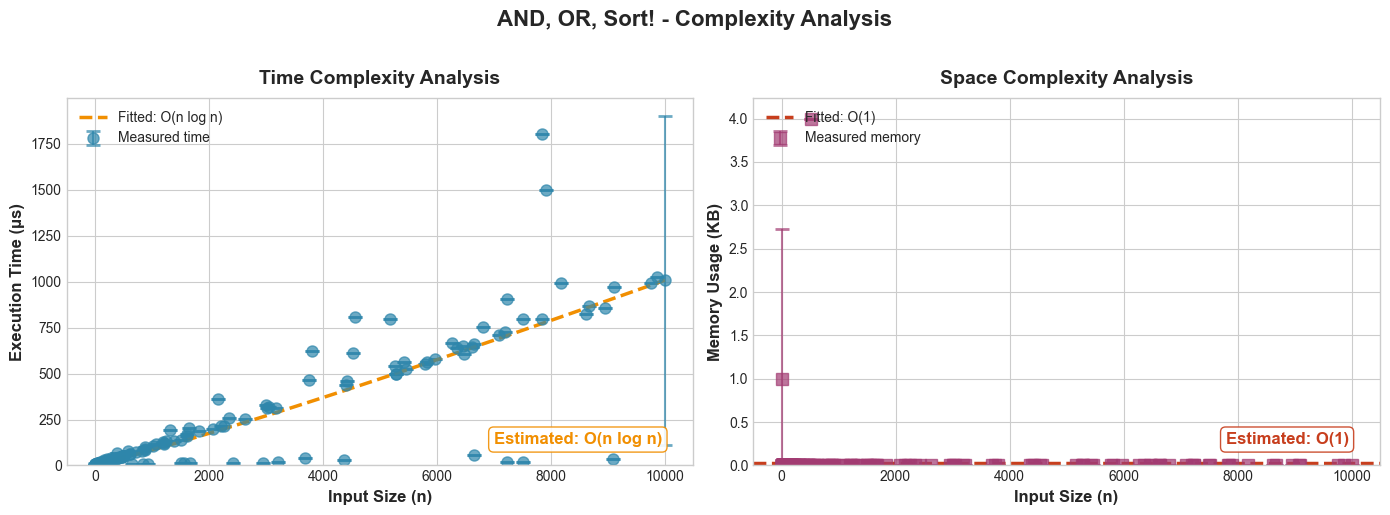


📊 Estimated Time Complexity: O(n log n)
📊 Estimated Space Complexity: O(1)
✅ The proposed solution meets both accuracy and efficiency requirements


In [7]:
##################### VERIFY PROPOSED SOLUTION ########################

print("\nTesting proposed solution on hidden tests:")
if internal_evaluation(test_file_path, proposed_solution, check_solution, parse_tests, TIME_LIMIT, MEMORY_LIMIT, get_input_size=get_input_size, plot_title='AND, OR, Sort!', show_estimation=True):
    print("✅ The proposed solution meets both accuracy and efficiency requirements")

<p style="padding: 20px;
          background-color: green;
          font-family: computermodern;
          color: white;
          font-size: 200%;
          text-align: center;
          border-radius: 40px 20px;
          ">Thank you! If you found this useful, please upvote 👍</p>